<h1 style="font-size:3em; font-family:fantasy; color:blue">Deep EDA and Stats Analysis</h1>

# Overview
<p>Analysis split into two level. Level 1 contain basic distribution analysis , visualizing plot, finding insight</p>
<p>Level 2 contain basic analysis that justify by statistic result </p>

In [22]:
# Importing libraries 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from scipy.stats import ttest_ind
from statsmodels.stats.outliers_influence import variance_inflation_factor

In [2]:
# Fetching Clean dataset without label encoded 
df =pd.read_csv("../Datasets/hotel_df_without_encoded.csv")

# Level-1 

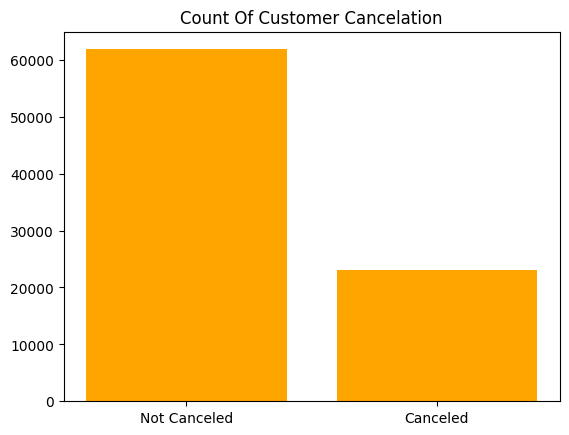

In [3]:
# Cancelation Count Plot
cancel_value = df['is_canceled'].value_counts()
labels =["Not Canceled" , "Canceled"]
plt.bar(labels , cancel_value.values,color="orange")
plt.title("Count Of Customer Cancelation")
plt.show()

<h1 style="color:darkblue;font-weight:700";>Insight-1</h1>
<ul style ="color:skyblue">
<li>Count of Customer Cancelation graph show customer not canceled booking are more then 60000 in compare to booking was canceled by customer that is approx 22000  </li>
<li>Booking not canceled is around 73 %</li>
<li>Booking was canceled is around 27 %</li>
</ul>


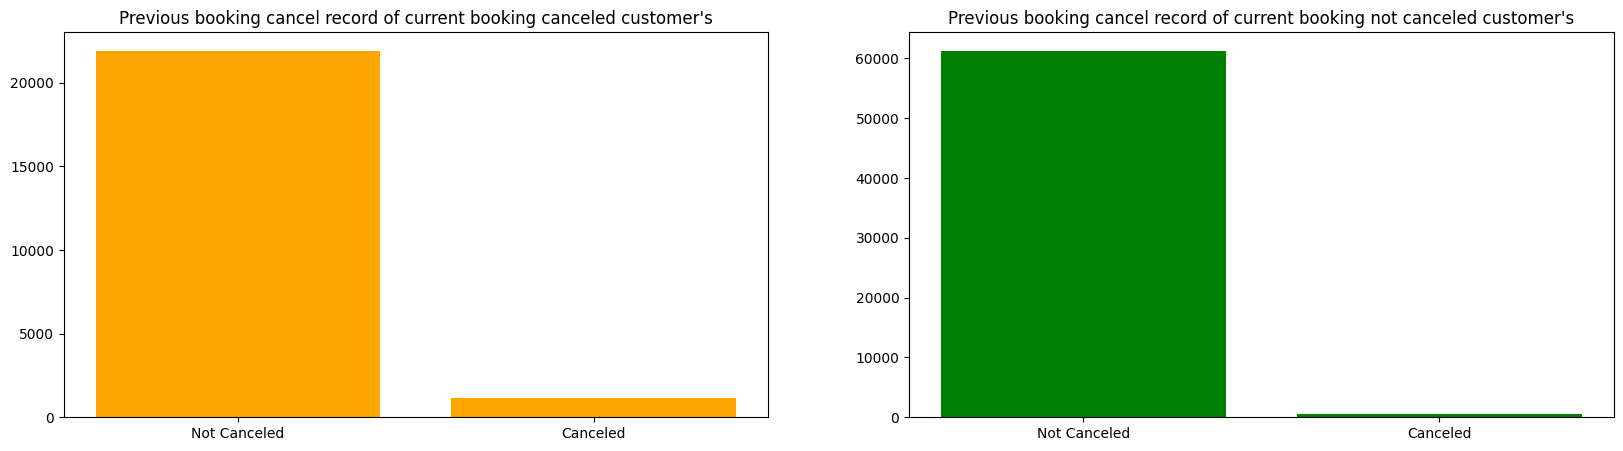

In [4]:
# current booking cancelletion customer previous cancelletion vs current booking not cancel customer previous cancelletion
is_not_cancel_query = df[df["is_canceled"]==0]
is_cancel_query=df[df["is_canceled"]==1]

plt.figure(figsize=(20,5))
plt.subplot(1,2,1)
plt.bar( labels,is_cancel_query[ "customer_cancel_indicator"].value_counts().values, color="orange")
plt.title("Previous booking cancel record of current booking canceled customer's")
plt.subplot(1,2,2)
plt.bar(labels, is_not_cancel_query["customer_cancel_indicator"].value_counts().values, color="green")
plt.title("Previous booking cancel record of current booking not canceled customer's")
plt.show()


<h1 style="color:darkblue;font-weight:700";>Insight-2</h1>
<ul style ="color:skyblue">
<li>Previous booking cancel  record by customer who cancel current booking previously canceled booking lower then 2000 and not canceled booking more then 20000  </li>
<li>Previous booking record  by customer who not cancel their booking previously canceled booking lower then 1000 and not canceled booking approx 60000  </li>

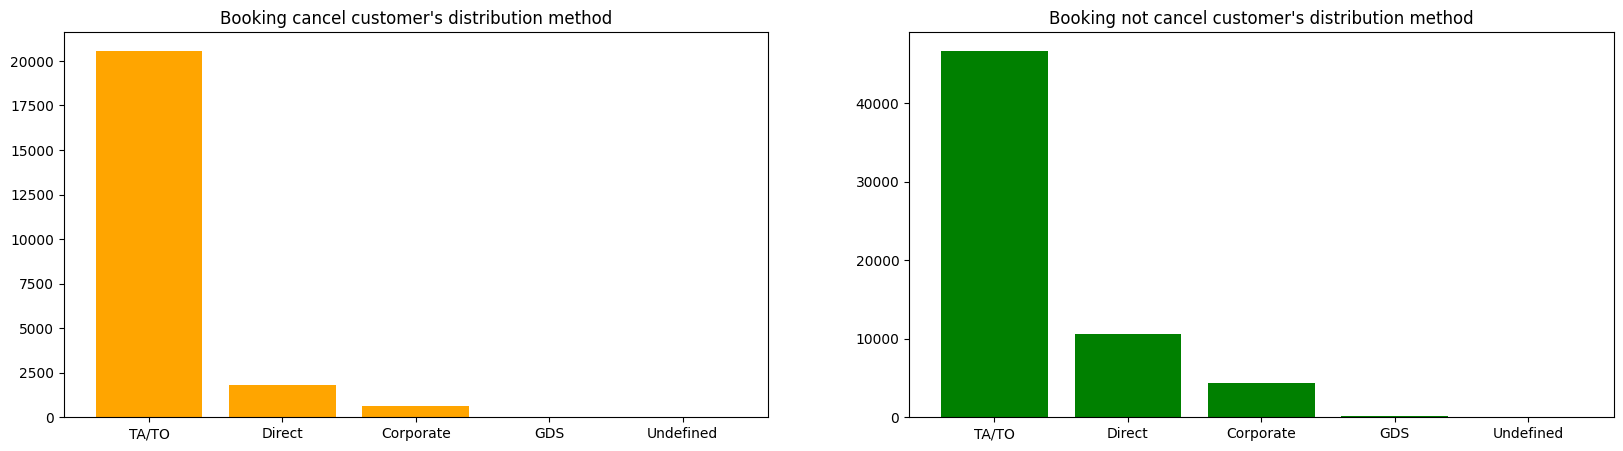

In [5]:
# booking cancel customer's distribution method of current booking cancel vs booking not cancel customer's distribution method
plt.figure(figsize=(20,5))
plt.subplot(1,2,1)
plt.bar(is_cancel_query["distribution_channel"].value_counts().keys() , is_cancel_query["distribution_channel"].value_counts().values, color="orange")
plt.title("Booking cancel customer's distribution method")

plt.subplot(1,2,2)
plt.bar(is_not_cancel_query["distribution_channel"].value_counts().keys(), is_not_cancel_query["distribution_channel"].value_counts().values, color="green")
plt.title("Booking not cancel customer's distribution method")
plt.show()

In [46]:
df["distribution_channel"].value_counts()
len(is_not_cancel_query[is_not_cancel_query["distribution_channel"]== "Corporate"])/len(df["distribution_channel"])*100

5.217534685416814

<h1 style="color:darkblue;font-weight:700";>Insight-3</h1>
<ul style ="color:skyblue">
<li>Most number of booking canceled by customer who booked their booking through TA/TO platform and also Most number of successfull booking made through this platform only this show are booking are heavly rely on TA/TO platform</li>
<li>Direct booking by customer were made around 12345 (8%) canceled by customer and Direct booking by customer were made around  (17%) were sucessfull 
</li>
<li>Corporate booking made by customer in total of 5076 in which booking canceled by customer around 0.7608414010788401 and  booking successfully done by customer around 5.217534685416814  </li>
<li>GDS and Undefined source not putting any effect because customer rare placed booking through this channel </li>

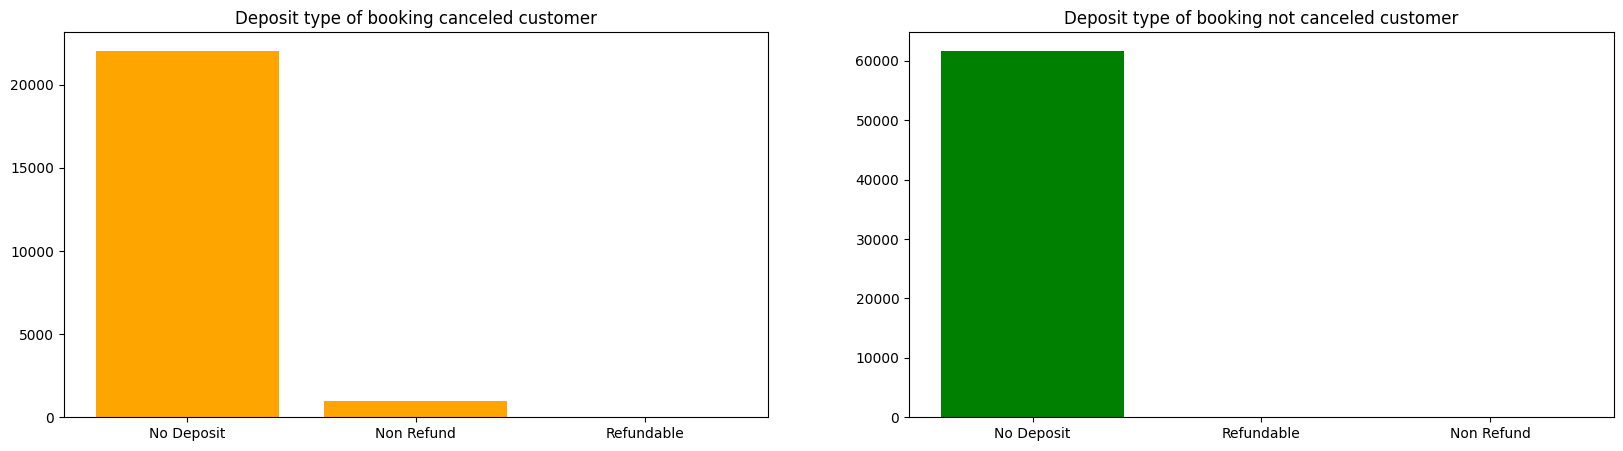

In [6]:
# Booking canceled customer deposit type vs booking not canceled customer's deposit type 
plt.figure(figsize=(20,5))
plt.subplot(1,2,1)
plt.bar(is_cancel_query["deposit_type"].value_counts().keys() , is_cancel_query["deposit_type"].value_counts().values, color='orange')
plt.title("Deposit type of booking canceled customer")
plt.subplot(1,2,2)
plt.bar(is_not_cancel_query["deposit_type"].value_counts().keys(), is_not_cancel_query["deposit_type"].value_counts().values, color='green')
plt.title("Deposit type of booking not canceled customer")
plt.show()

In [54]:
is_cancel_query["deposit_type"].value_counts()
len(is_not_cancel_query[is_not_cancel_query["deposit_type"]=="No Deposit"])/ len(df) *100

72.68155371822958

<h1 style="color:darkblue;font-weight:700";>Insight-4</h1>
<ul style ="color:skyblue">
<li>When customer cancel their booking hotel generally rarely refunded their amount back otherwise customer who made prior payment for their booking and cancel it they endup getting no refund it about 2% </li>
<li>That why customer tried to avoid make any prior payment for their booking almost 26%
</li>
<li>Same goes to customer who have done successfull booking had not pay any upfront payment toward's their booking is around 73%  </li>


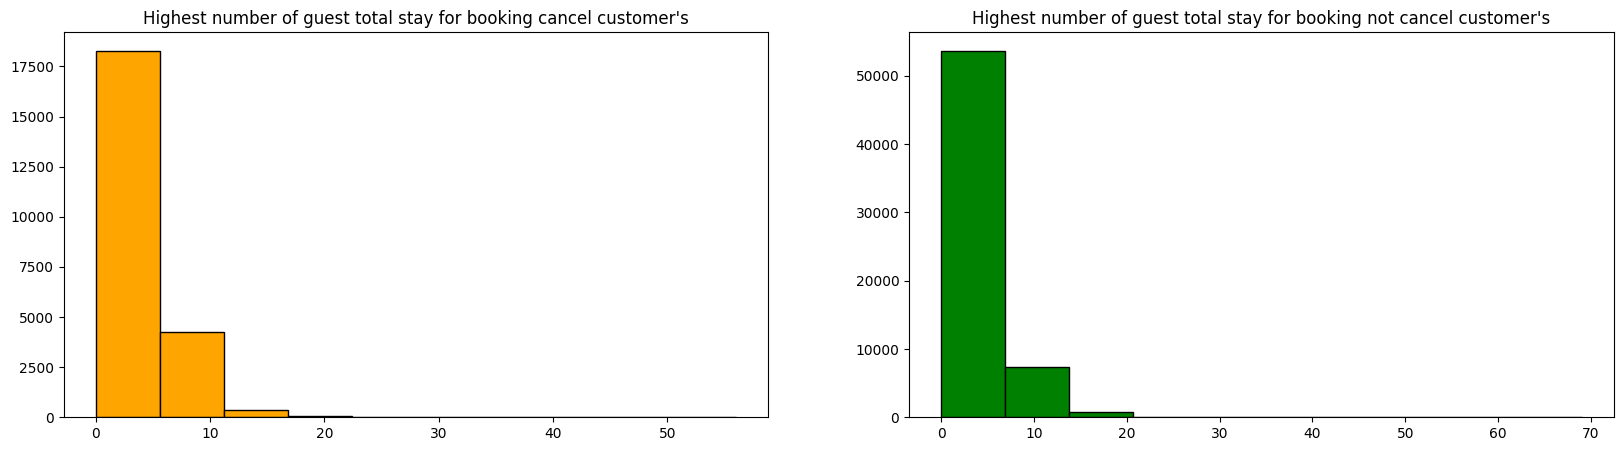

In [7]:
plt.figure(figsize=(20,5))
plt.subplot(1,2,1)
plt.hist(is_cancel_query["guest_total_stay"], edgecolor="black", color="orange")
plt.title("Highest number of guest total stay for booking cancel customer's")
plt.subplot(1,2,2)
plt.hist(is_not_cancel_query["guest_total_stay"],edgecolor="black",color="green")
plt.title("Highest number of guest total stay for booking not cancel customer's")
plt.show()

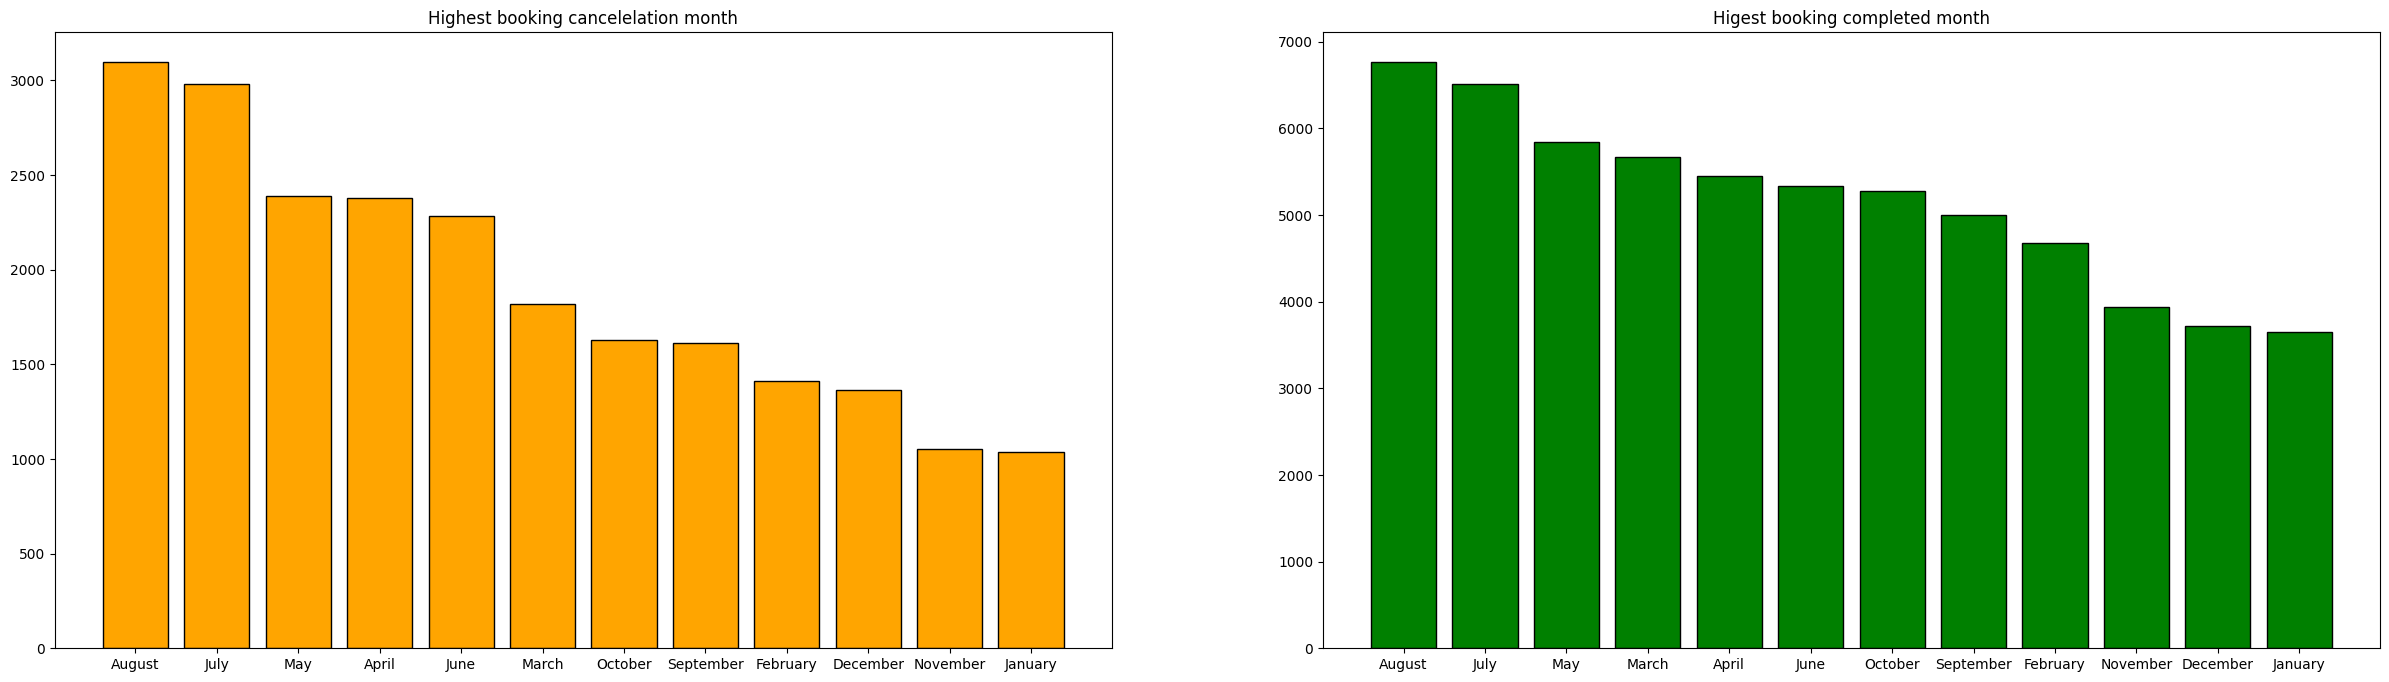

In [8]:
# maximum number of booking cancel month vs maximum number of booking not cancel month
plt.figure(figsize=(30,8))
plt.subplot(1,2,1)
plt.bar(is_cancel_query["arrival_date_month"].value_counts().keys() , is_cancel_query["arrival_date_month"].value_counts().values, color='orange',edgecolor="black")
plt.title("Highest booking cancelelation month")
plt.subplot(1,2,2)
plt.bar(is_not_cancel_query["arrival_date_month"].value_counts().keys(), is_not_cancel_query["arrival_date_month"].value_counts().values,color='green',edgecolor='black') 
plt.title("Higest booking completed month")
plt.show()

<h1 style="color:darkblue;font-weight:700";>Insight-5</h1>
<ul style ="color:skyblue">
<li>Peak booking activity occurs in July and August, where both cancellations and completions are at their highest levels.</li>
<li>Although cancellations are significant in these months (3000), completions are more than double (7000), showing strong demand outweighs cancellations.</li>
<li>Low activity months are November, December, and January, with both cancellations and completions dropping to nearly half of peak season levels.</li>
<li>This seasonality suggests businesses should allocate more resources in July–August and use targeted promotions in off-season months to boost demand.</li>
</ul>

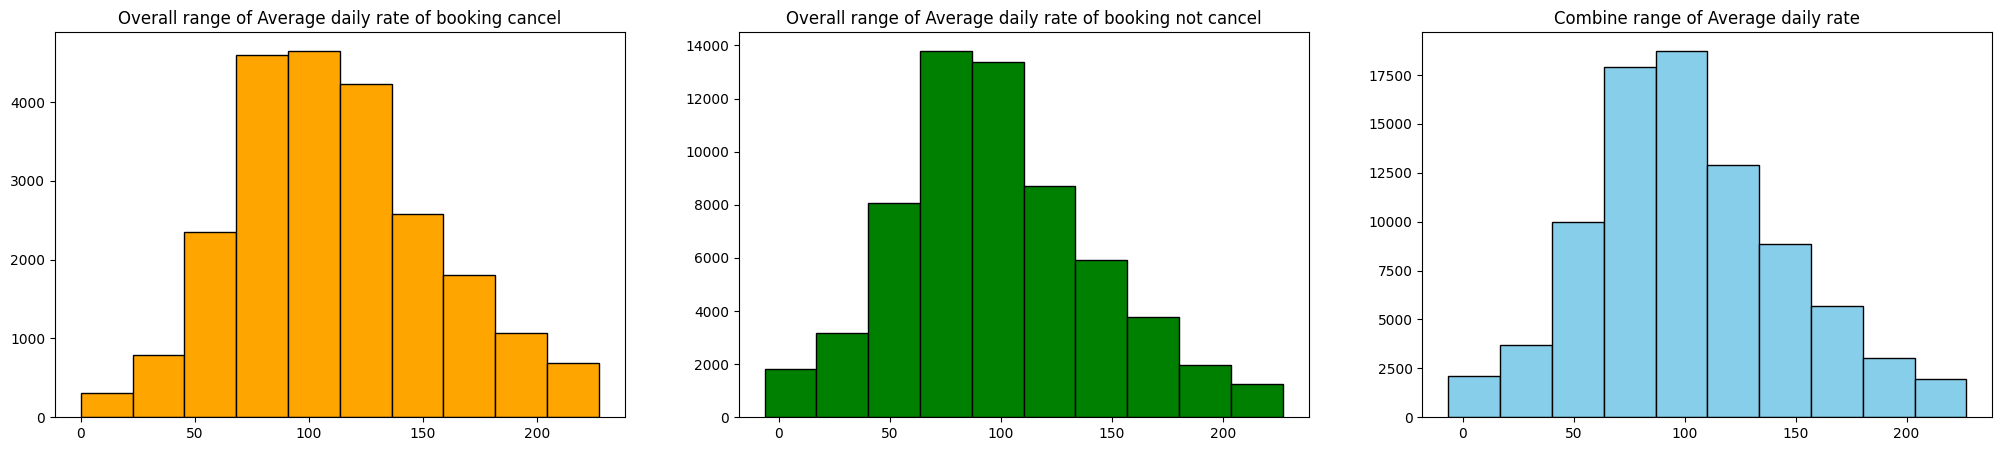

In [9]:
# reservation changes request customers 
plt.figure(figsize=(25,5))
plt.subplot(1,3,1)
plt.hist(is_cancel_query["adr"], edgecolor="black", color='orange')
plt.title("Overall range of Average daily rate of booking cancel")
plt.subplot(1,3,2)
plt.hist(is_not_cancel_query["adr"],edgecolor='black', color='green')
plt.title("Overall range of Average daily rate of booking not cancel")
plt.subplot(1,3,3)
plt.hist(df["adr"],edgecolor='black', color='skyblue')
plt.title("Combine range of Average daily rate")
plt.show()

<h1 style="color:darkblue;font-weight:700";>Insight-6</h1>
<ul style ="color:skyblue">
<li>Bookings that were canceled show a narrower distribution of average daily rates, with most cancellations clustering between 50–150 units.</li>
<li>Non-canceled bookings dominate the distribution, with much higher frequencies across the same range, peaking strongly around mid-range daily rates.</li>
<li>The combined view highlights that successful bookings far outweigh cancellations, suggesting customers are more likely to follow through when rates are moderate rather than extreme.</li>
<li>This indicates pricing strategy plays a key role: moderate average daily rates encourage completion, while extreme rates (too low or too high) are more prone to cancellation.</li>
</ul>

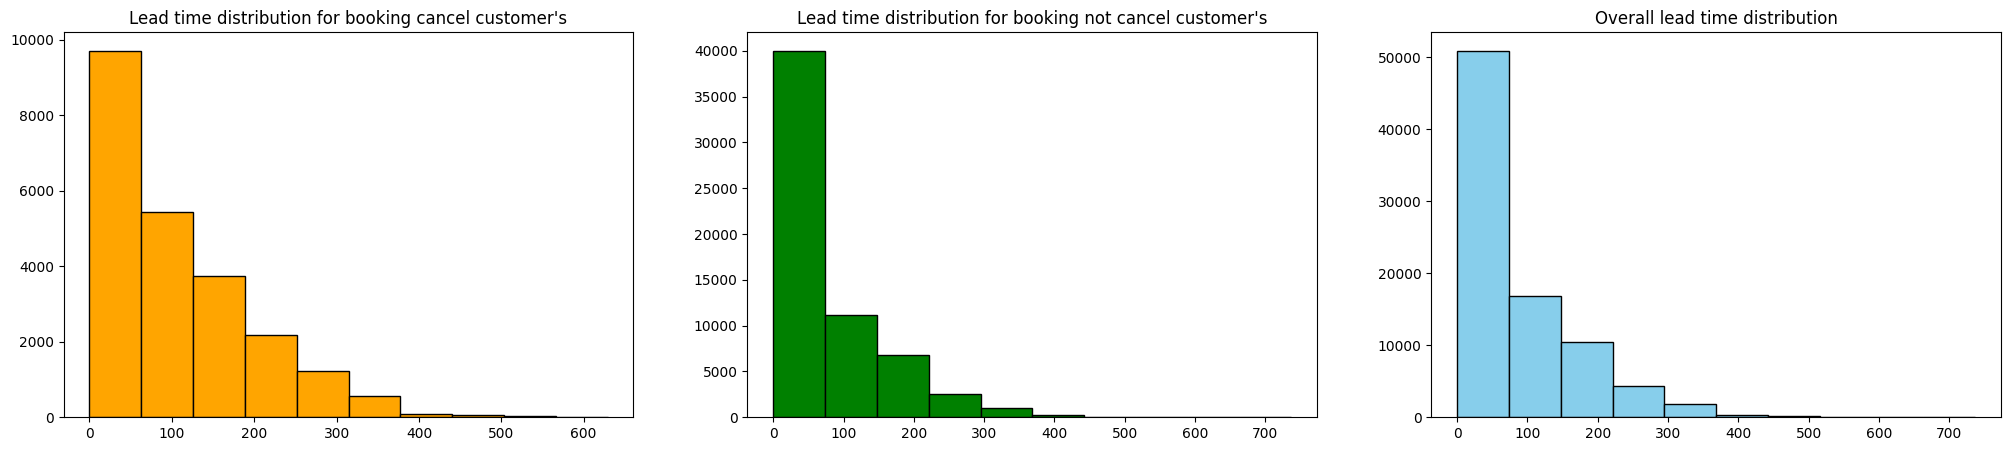

In [10]:
# lead time distribution plot
plt.figure(figsize=(25,5))
plt.subplot(1,3,1)
plt.hist(is_cancel_query["lead_time"], edgecolor="black", color='orange')
plt.title("Lead time distribution for booking cancel customer's")
plt.subplot(1,3,2)
plt.hist(is_not_cancel_query["lead_time"],edgecolor='black', color='green')
plt.title("Lead time distribution for booking not cancel customer's")
plt.subplot(1,3,3)
plt.hist(df["lead_time"],edgecolor='black', color='skyblue')
plt.title("Overall lead time distribution")
plt.show()

<h1 style="color:darkblue;font-weight:700";>Insight-7</h1>
<ul style ="color:skyblue">
<li>Both canceled and non-canceled bookings show a right-skewed lead time distribution, meaning most bookings are made with shorter lead times.</li>
<li>Canceled bookings peak heavily at short lead times, suggesting customers who book closer to their stay date are more likely to cancel.</li>
<li>Non-canceled bookings dominate overall volume, especially in the short lead time range, showing that last-minute bookings are common but often completed successfully.</li>
<li>The combined distribution confirms that short lead times drive the majority of booking activity, highlighting the importance of managing last-minute demand and cancellation risk.</li>
</ul>

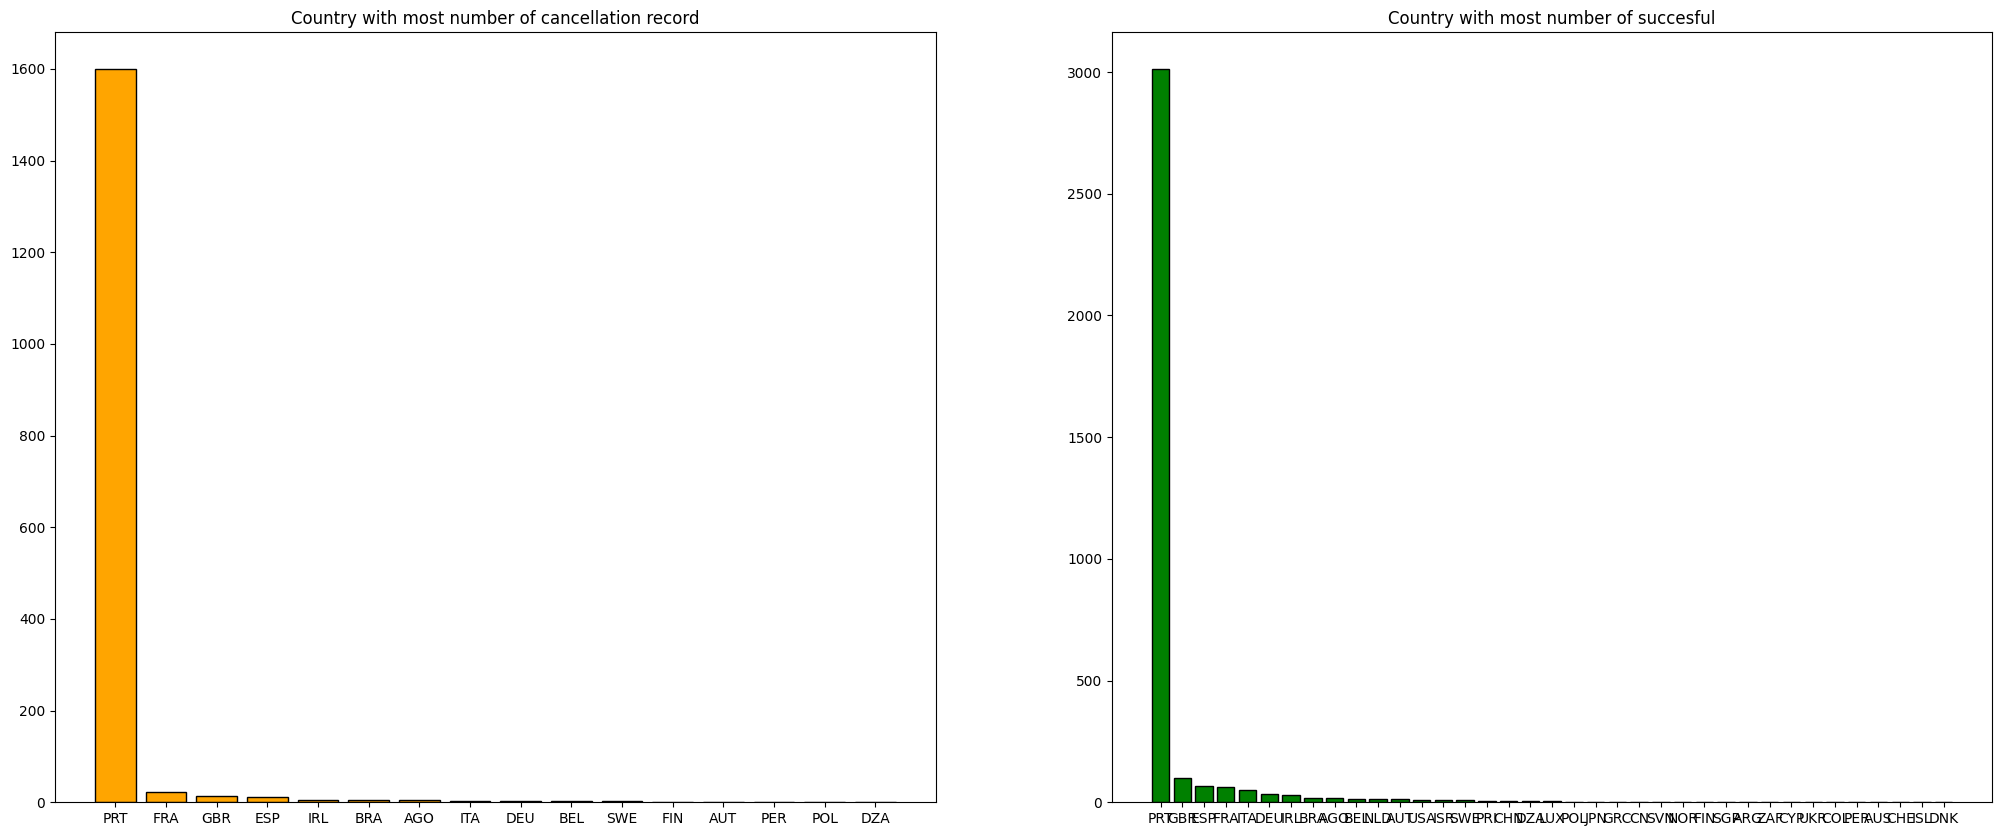

In [11]:
# Identifying which country customers have most number of cancel booking and which have most number of complete booking
query_1 =df[df['previous_cancellations']!= 0]
query_2 =df[df["previous_bookings_not_canceled"]!=0]
plt.figure(figsize=(25,10))
plt.subplot(1,2,1)
plt.bar(query_1["country"].value_counts().keys(),query_1["country"].value_counts().values, edgecolor='black', color="orange")
plt.title("Country with most number of cancellation record")
plt.subplot(1,2,2)
plt.bar(query_2["country"].value_counts().keys(), query_2["country"].value_counts().values,edgecolor='black', color="green")
plt.title("Country with most number of succesful") 
plt.show()

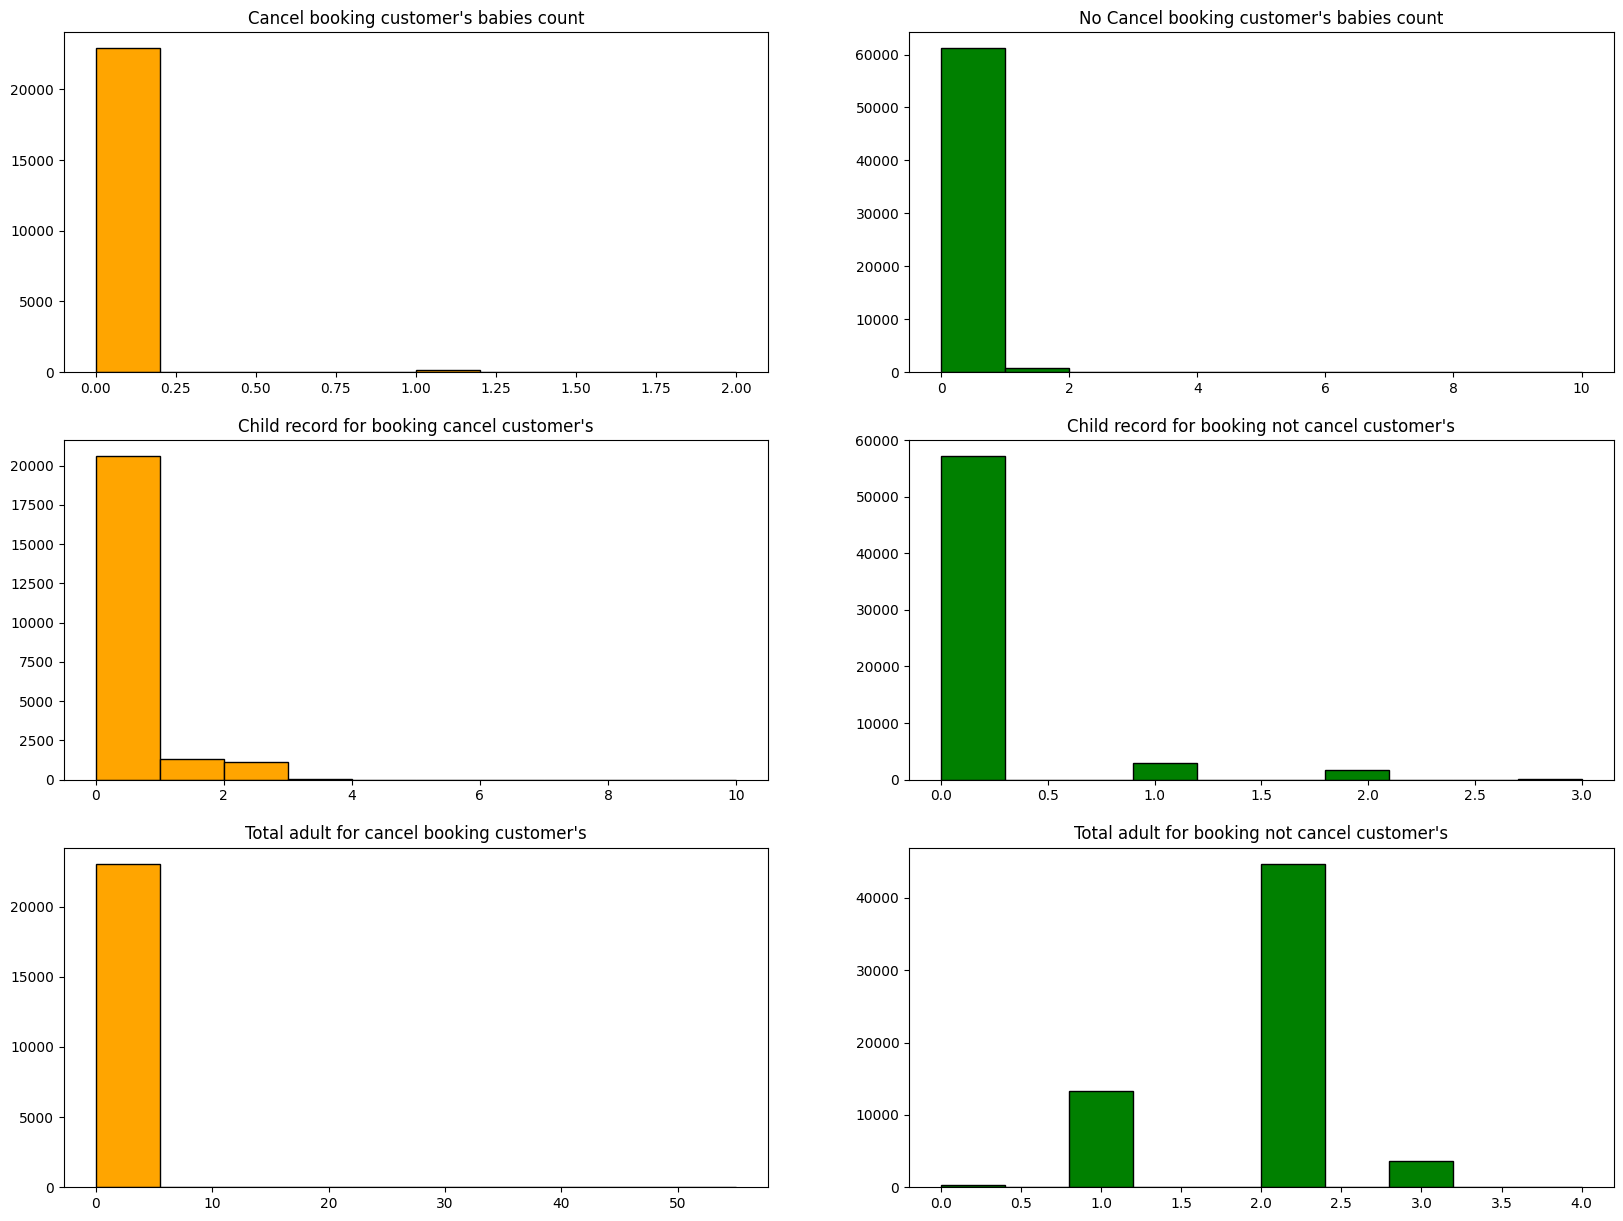

In [12]:
# customer's with not cancel booking babies count
plt.figure(figsize=(20,15))
plt.subplot(3,2,1)
plt.hist(is_cancel_query["babies"], edgecolor='black', color='orange')
plt.title("Cancel booking customer's babies count")
plt.subplot(3,2,2)
plt.hist(is_not_cancel_query["babies"], edgecolor='black', color='green')
plt.title("No Cancel booking customer's babies count")
plt.subplot(3,2,3)
plt.hist(is_cancel_query['children'],edgecolor='black', color='orange')
plt.title("Child record for booking cancel customer's")
plt.subplot(3,2,4)
plt.hist(is_not_cancel_query['children'],edgecolor='black', color='green')
plt.title("Child record for booking not cancel customer's")
plt.subplot(3,2,5)
plt.hist(is_cancel_query["adults"],edgecolor="black", color="orange")
plt.title("Total adult for cancel booking customer's")
plt.subplot(3,2,6)
plt.hist(is_not_cancel_query["adults"],edgecolor='black', color='green')
plt.title("Total adult for booking not cancel customer's")
plt.show()

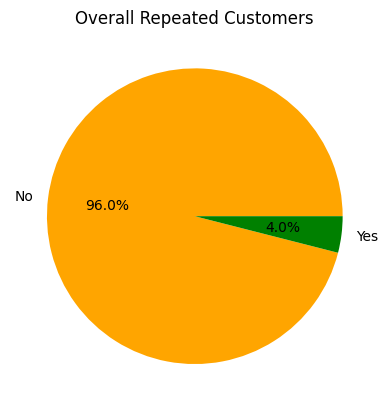

In [13]:
# Loyalty plot 
plt.pie(df["is_repeated_guest"].value_counts().values,labels= ["No" , "Yes"], autopct="%1.1f%%", colors=["orange","green"]  )
plt.title("Overall Repeated Customers")
plt.show()

<h1 style="color:darkblue;font-weight:700";>Insight-8</h1>
<ul style ="color:skyblue">
<li>Hotel are not able to retain their customer after first booking. Rate of repeated customer is around 4% and New customer is 96%</li>
</ul>

# Level 2

In [14]:
def find_insight_1(para):
    # data len
    df_len = len(df)
    for i in df[para].value_counts().keys():
        # cancelled booking
        query =df[(df[para]==i) & (df["is_canceled"]==1)]
        # confirm booking
        query_b = df[(df[para]==i) & (df["is_canceled"]==0)]
        # Average adr between cancel and non-cancel booking
        # adr average for cancel booking
        adr_cancel = query["adr"].mean()
        # adr average for confirm booking
        adr_confirm = query_b["adr"].mean()
        # lead time average for cancel booking
        lead_cancel = query["lead_time"].mean()
        lead_confirm = query_b["lead_time"].mean()
        print(f"Analysis of {i}")
        print(f"Cancellelation Rate of {i} :{len(query)/df_len *100}")
        print(f"Average Adr Rate for cancel booking of {i} :{adr_cancel}")
        print(f"Average Adr Rate for confirm booking of {i} :{adr_confirm}")
        print(f"Average of Lead time for cancel booking of {i} :{lead_cancel}")
        print(f"Average of Lead time for confirm booking of {i} :{lead_confirm}")
        print("____________________________________________________________________")

In [58]:
find_insight_1("hotel")

Analysis of City Hotel
Cancellelation Rate of City Hotel :18.572303488563826
Average Adr Rate for cancel booking of City Hotel :114.5731428752616
Average Adr Rate for confirm booking of City Hotel :106.30873108833578
Average of Lead time for cancel booking of City Hotel :102.38918130509227
Average of Lead time for confirm booking of City Hotel :67.64833794262783
____________________________________________________________________
Analysis of Resort Hotel
Cancellelation Rate of Resort Hotel :8.587143429204062
Average Adr Rate for cancel booking of Resort Hotel :105.42732684131119
Average Adr Rate for confirm booking of Resort Hotel :85.93194159589808
Average of Lead time for cancel booking of Resort Hotel :114.85132354958168
Average of Lead time for confirm booking of Resort Hotel :74.39236500560807
____________________________________________________________________


In [59]:
find_insight_1("distribution_channel")

Analysis of TA/TO
Cancellelation Rate of TA/TO :24.238569712387818
Average Adr Rate for cancel booking of TA/TO :113.0696433430515
Average Adr Rate for confirm booking of TA/TO :100.58196194267857
Average of Lead time for cancel booking of TA/TO :111.61744412050534
Average of Lead time for confirm booking of TA/TO :79.05316894625314
____________________________________________________________________
Analysis of Direct
Cancellelation Rate of Direct :2.1129248816338064
Average Adr Rate for cancel booking of Direct :107.92926978818282
Average Adr Rate for confirm booking of Direct :99.82107667519666
Average of Lead time for cancel booking of Direct :71.83221850613155
Average of Lead time for confirm booking of Direct :48.46592740024642
____________________________________________________________________
Analysis of Corporate
Cancellelation Rate of Corporate :0.7608414010788401
Average Adr Rate for cancel booking of Corporate :77.77136222910217
Average Adr Rate for confirm booking of Corp

In [60]:
find_insight_1("market_segment")

Analysis of Online TA
Cancellelation Rate of Online TA :20.5250512331284
Average Adr Rate for cancel booking of Online TA :118.39858323291445
Average Adr Rate for confirm booking of Online TA :110.42560570071258
Average of Lead time for cancel booking of Online TA :103.23503758535605
Average of Lead time for confirm booking of Online TA :67.63074929820773
____________________________________________________________________
Analysis of Offline TA/TO
Cancellelation Rate of Offline TA/TO :2.417968105905354
Average Adr Rate for cancel booking of Offline TA/TO :88.36724305893814
Average Adr Rate for confirm booking of Offline TA/TO :79.38922104369962
Average of Lead time for cancel booking of Offline TA/TO :134.98538723818803
Average of Lead time for confirm booking of Offline TA/TO :101.09435723377175
____________________________________________________________________
Analysis of Direct
Cancellelation Rate of Direct :1.8926813181636162
Average Adr Rate for cancel booking of Direct :115.51

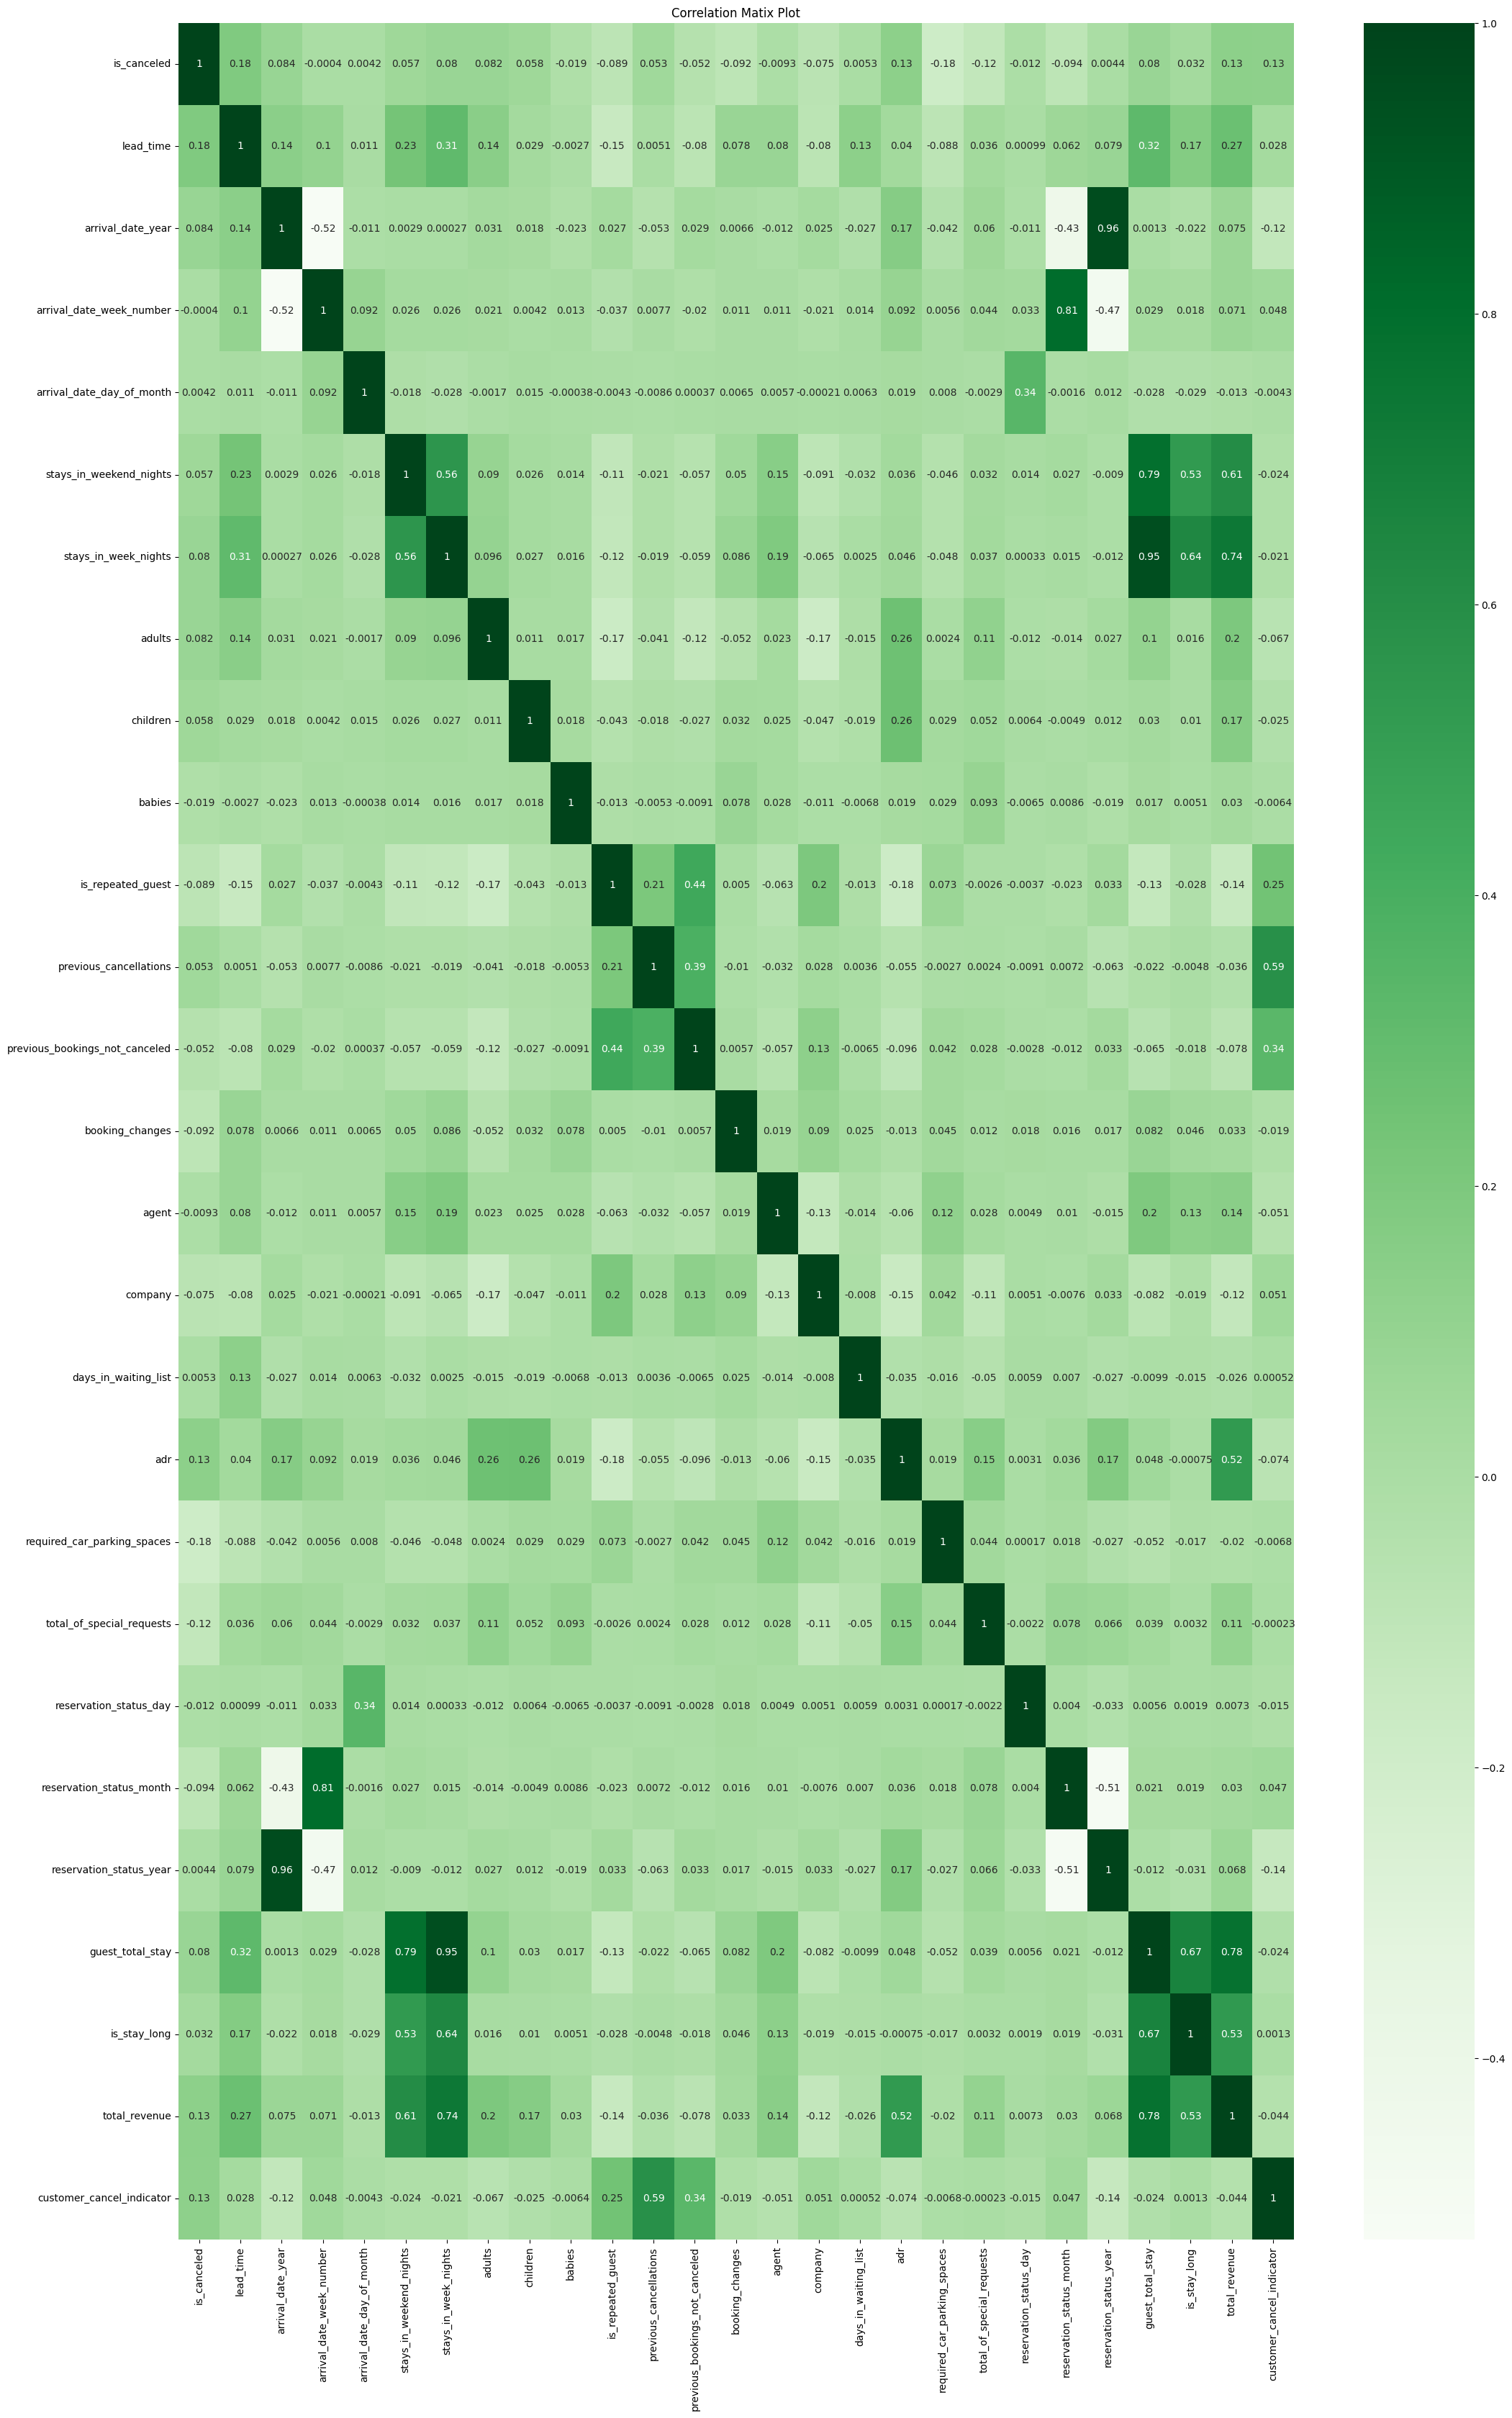

In [15]:
# correlation matrix
numric_col = [i  for i in df.columns if df[i].dtype != object]
corr = df[numric_col].corr()
plt.figure(figsize=(25,40))
sns.heatmap(corr, annot=True, cmap="Greens")
plt.title("Correlation Matix Plot")
plt.show()

<h1 style="color:darkblue;font-weight:700";>Insight-9</h1>
<ul style ="color:skyblue">
<li><b>Lead Time:</b> Shows a positive correlation with cancellations (0.18). Longer lead times increase the likelihood of cancellation, which aligns with the histogram insights.</li>
<li><b>ADR (Average Daily Rate):</b> Positively correlated with cancellations (0.13). Higher room rates slightly increase cancellation risk, suggesting price sensitivity.</li>
<li><b>Parking Spaces & Special Requests:</b> Required car parking spaces (-0.18) and total special requests (-0.11) are negatively correlated with cancellations. Guests making more specific requests or requiring parking are less likely to cancel, indicating stronger booking intent.</li>
<li><b>Guest Stay Length:</b> Total stay duration (0.08) and weeknight/weekend nights both show positive correlation with cancellations. Longer stays carry higher cancellation risk.</li>
<li><b>Repeated Guests:</b> Strong negative correlation (-0.09). Repeat customers are less likely to cancel, highlighting loyalty as a stabilizing factor.</li>
<li><b>Revenue:</b> Total revenue correlates positively with cancellations (0.13). High-value bookings face greater cancellation risk, possibly due to higher ADR or longer stays.</li>
<li><b>Customer Cancel Indicator:</b> Strongly aligned with cancellation (0.13), validating its predictive role in models.</li>
</ul>

In [16]:
def find_insight_2(para):
    cancel_value = df[df["is_canceled"]==1][para]
    confirm_value =df[df["is_canceled"]==0][para]
    t_stat, p_value = ttest_ind(cancel_value , confirm_value, equal_var=False)
    print(f"t_stat:{t_stat}, p_value: {p_value}") 
    print(f"Cancel Booking Mean:{cancel_value.mean()} and Booking not cancel:{confirm_value.mean()}")

In [17]:
# Repeated customers vs first time customer
def find_insight_3():
    # repeated client
    repeated =df[df["is_repeated_guest"]==1]
    # first time client
    non_repeated =df[df["is_repeated_guest"]==0]
    # booking cancel for repeated customer
    repeated_cancel= repeated[repeated['is_canceled']==1]
    repeated_not_cancel= repeated[repeated["is_canceled"]==0]
    # booking cancel for non repeated customer
    non_repeated_cancel = non_repeated[non_repeated['is_canceled']==1]
    non_repeated_not_cancel= non_repeated[non_repeated["is_canceled"]==0]
    # total record of dataset
    len_df = len(df)
    # cancelelation likehood 
    #repeated customers 
    cancel_likehood_repeated = np.round(len(repeated_cancel)/len(repeated)*100)
    not_cancel_likehood_repeated = np.round(len(repeated_not_cancel)/len(repeated)*100)
    #not repeated customer's
    cancel_likehood_not_repeated = np.round(len(non_repeated_cancel)/len(non_repeated)*100)
    not_cancel_likehood_not_repeated =  np.round(len(non_repeated_not_cancel)/len(non_repeated)*100)
    print(f"Cancel rate of repeated customers: {cancel_likehood_repeated} , Cancel rate of non repeated customers:{cancel_likehood_not_repeated}")
    print(f"Confirm rate of repeated customers:{not_cancel_likehood_repeated} , Confirm rate of non repeated customers: {not_cancel_likehood_not_repeated}")
    print(
    f"ADR of repeated customers who cancel booking: {repeated_cancel['adr'].mean()} vs "
    f"ADR of repeated customers who not cancel booking: {repeated_not_cancel['adr'].mean()}")
    print(
    f"ADR of repeated customers who cancel booking: {non_repeated_cancel['adr'].mean()} vs "
    f"ADR of repeated customers who not cancel booking: {non_repeated_not_cancel['adr'].mean()}")
    print(
    f"Revenue Lost Due to cancel of repeated customer: {sum(repeated['adr'] * repeated['guest_total_stay'] * repeated['is_canceled'])}")
    print(
    f"Revenue Lost Due to cancel of not repeated customer: {sum(non_repeated['adr'] * non_repeated['guest_total_stay'] * non_repeated['is_canceled'])}"
    )
    
    
    
    

In [62]:
find_insight_3()

Cancel rate of repeated customers: 8.0 , Cancel rate of non repeated customers:28.0
Confirm rate of repeated customers:92.0 , Confirm rate of non repeated customers: 72.0
ADR of repeated customers who cancel booking: 77.30418604651163 vs ADR of repeated customers who not cancel booking: 60.9772394998397
ADR of repeated customers who cancel booking: 112.07043461099903 vs ADR of repeated customers who not cancel booking: 100.05441449418497
Revenue Lost Due to cancel of repeated customer: 55502.66999999999
Revenue Lost Due to cancel of not repeated customer: 10247889.50000004


<h1 style="color:darkblue;font-weight:700";>Insight-10</h1>
<ul style ="color:skyblue">
<li><b>Cancellation Behavior:</b> Repeated customers have a much lower cancel rate (8%) compared to non-repeated customers (28%), showing stronger loyalty and commitment.</li>
<li><b>Confirmation Behavior:</b> Repeated customers confirm 92% of their bookings, while non-repeated customers confirm only 72%, reinforcing the reliability of loyal guests.</li>
<li><b>ADR Comparison:</b> For repeated customers, ADR is higher when they cancel (77.30) than when they confirm (60.98). For non-repeated customers, ADR is also higher when they cancel (112.07) compared to when they confirm (100.05). This suggests higher-priced bookings are more prone to cancellation.</li>
<li><b>Revenue Impact:</b> Revenue lost due to cancellations of repeated customers is relatively small (≈55.5K), while cancellations from non-repeated customers cause massive losses (≈10.25M). This highlights the financial importance of cultivating repeat guests.</li>


In [18]:
def find_insight_4():
    # total revenue loss
    total_loss = (df["adr"] * df["guest_total_stay"] * df["is_canceled"]).sum()
    
    # revenue loss by hotel type, customer type, and booking channel
    col = ["customer_type", "hotel", "distribution_channel"]
    revenue_dict = {}
    
    for i in col:
        revenue_dict[i] = {}
        keys = df[i].value_counts().keys()
        for j in keys:
            query = df[df[i] == j]
            revenue = (query["adr"] * query["guest_total_stay"] * query["is_canceled"]).sum()
            revenue_dict[i][j] = revenue
    
    return {"total_loss": total_loss, "breakdown": revenue_dict}
    

In [63]:
find_insight_4() 

{'total_loss': 10303392.170000002,
 'breakdown': {'customer_type': {'Transient': 9568115.450000001,
   'Transient-Party': 483953.75999999995,
   'Contract': 236196.37,
   'Group': 15126.59},
  'hotel': {'City Hotel': 6360921.149999999,
   'Resort Hotel': 3942471.0200000005},
  'distribution_channel': {'TA/TO': 9353837.94,
   'Direct': 789730.26,
   'Corporate': 146367.01,
   'GDS': 12849.46,
   'Undefined': 607.5}}}

<h1 style="color:darkblue;font-weight:700";>Insight-11</h1>
<ul style ="color:skyblue">
<li><b>Total Revenue Loss:</b> ≈ 10.3M due to cancellations across all customer types, hotels, and channels.</li>
<li><b>By Customer Type:</b> Transient customers account for the largest share of losses (≈9.57M), followed by Transient-Party (≈0.48M), Contract (≈0.24M), and Group (≈0.015M). This shows transient guests drive most cancellation risk.</li>
<li><b>By Hotel Type:</b> City Hotels lost ≈6.36M, while Resort Hotels lost ≈3.94M. City Hotels bear a heavier cancellation burden.</li>
<li><b>By Distribution Channel:</b> Travel Agents/Tour Operators (TA/TO) dominate losses (≈9.35M), far exceeding Direct (≈0.79M), Corporate (≈0.15M), and GDS (≈0.013M). This highlights TA/TO as the most vulnerable channel for cancellations.</li>


# Deep Feature Engineering on final dataset 

In [19]:
df_2 = pd.read_csv('../Datasets/hotel_df_with_encoded.csv')

In [32]:
col = df_2.drop('is_canceled', axis=1)
vif_df = pd.DataFrame()
vif_df["Column"]=col.columns
vif_df["Vif_Score"]=[variance_inflation_factor(col.values, i) for i in range(col.shape[1])] 
vif_df["Impact"] = [ "High" if i > 5 else "Low" for i in vif_df["Vif_Score"].values]

C:\Users\gautam\new_folder\newenv\lib\site-packages\statsmodels\stats\outliers_influence.py:197: RuntimeWarning: divide by zero encountered in scalar divide
  vif = 1. / (1. - r_squared_i)


In [33]:
vif_df

,Column,Vif_Score,Impact
0,hotel,4.058170e+00,Low
1,lead_time,2.814594e+00,Low
2,arrival_date_year,4.595346e+08,High
3,arrival_date_month,3.820287e+00,Low
4,arrival_date_week_number,4.842204e+01,High
5,arrival_date_day_of_month,4.875558e+00,Low
6,stays_in_weekend_nights,inf,High
7,stays_in_week_nights,inf,High
8,adults,1.174637e+01,High
9,children,1.268602e+00,Low


<h1 style="color:darkblue;font-weight:700";>Insight-11</h1>
<ul style ="color:skyblue">
<li><b>High Multicollinearity:</b> Variables such as <i>arrival_date_year</i> (4.59e+08), <i>arrival_date_week_number</i> (48.42), <i>stays_in_weekend_nights</i> (∞), <i>stays_in_week_nights</i> (∞), <i>guest_total_stay</i> (∞), <i>adults</i> (11.74), <i>market_segment</i> (73.50), <i>distribution_channel</i> (39.03), <i>customer_type</i> (17.89), <i>adr</i> (19.08), <i>total_revenue</i> (14.83), and <i>reservation_status_year</i> (4.59e+08) show very high VIF scores, indicating strong multicollinearity.</li>
<li><b>Low Impact Variables:</b> Features like <i>children</i>, <i>babies</i>, <i>meal</i>, <i>is_repeated_guest</i>, <i>previous_cancellations</i>, <i>booking_changes</i>, <i>deposit_type</i>, <i>days_in_waiting_list</i>, and <i>required_car_parking_spaces</i> have low VIF scores, suggesting minimal collinearity and safer inclusion in models.</li>
<li><b>Moderate Risk:</b> Variables such as <i>hotel</i> (4.05), <i>arrival_date_month</i> (3.82), <i>reserved_room_type</i> (4.57), <i>assigned_room_type</i> (4.81), and <i>reservation_status_day</i> (5.04) show moderate VIF values, requiring monitoring but not immediate removal.</li>

